## **5° Module (b)**: TT - Fidelity Kernels & Bandwidth Sweep
* September 24°, 2026
#### ESCOM - IPN:

#### *B.S. in Computer Science*
> Miguel Alexander Sanchez Garcia

#### **0° Introduction**

This notebook measures similarities between lesions after the two fixed quantum feature maps. Masses and calcifications remain separate, and all kernel calculations use a reproducible, stratified sample of 200 training lesions (D-028).

For encoded states $|\phi(\mathbf{x})\rangle$, the fidelity kernel is $K_Q(\mathbf{x},\mathbf{x}')=|\langle\phi(\mathbf{x})|\phi(\mathbf{x}')\rangle|^2$. It compares complete encoded states, including phase information, whereas the cached expectation-value embeddings are a different object.

Only the feature map is used: the kernel is a property of the encoding itself, so an ansatz would introduce unrelated trainable structure (D-017). `FidelityStatevectorKernel` implements the same fidelity definition through statevectors; with `shots=None` it is exact and is substantially faster in simulation. A real device does not provide statevectors, so that shortcut is unavailable there (OE-6).

The primary analysis retains the preregistered angles ($c=1$). The bandwidth sweep evaluates $c\mathbf{x}$ for several $c$ values to quantify the observed concentration without replacing that design (D-029).

#### **1° Setup**

**a.** Import the libraries and define fixed paths

In [1]:
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import qiskit
import qiskit_machine_learning
from qiskit.circuit.library import pauli_feature_map, zz_feature_map
from qiskit.quantum_info import Statevector
from qiskit_machine_learning.kernels import FidelityQuantumKernel, FidelityStatevectorKernel
from sklearn.model_selection import StratifiedShuffleSplit

warnings.filterwarnings('ignore')
print(f'Qiskit: {qiskit.__version__}; qiskit-machine-learning: {qiskit_machine_learning.__version__}')

Qiskit: 2.3.0; qiskit-machine-learning: 0.9.0


**b.** Configure the reproducible analysis

In [2]:
SEED = 42
N_SUBSAMPLE = 200
SCALES = [1.0, 0.5, 0.2, 0.1, 0.05, 0.02]
ROOT = Path('/Users/alexander_san/TT')
IN_DIR = ROOT / 'Data/processed/m4'
OUT_DIR = ROOT / 'Data/processed/m5'
RESULTS_DIR = ROOT / 'Code/results'
FIG_DIR = ROOT / 'Docs/Figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
FINDINGS = ['mass', 'calcification']
print(f'Input: {IN_DIR}')
print(f'Output: {OUT_DIR}')

Input: /Users/alexander_san/TT/Data/processed/m4
Output: /Users/alexander_san/TT/Data/processed/m5


#### **2° Reproducible stratified samples**

**a.** Select 200 lesions in the documented input order

The splitter receives the full training rows for each finding type after resetting their index. Its returned test indices are retained without sorting, so the saved lesion list is also the row order of every kernel matrix.

In [3]:
data, samples, Xs, ys = {}, {}, {}, {}
subsample_rows = []
for finding in FINDINGS:
    frame = pd.read_parquet(IN_DIR / f'x_{finding}.parquet')
    feature_cols = [c for c in frame.columns if c.startswith('x_')]
    assert feature_cols == [f'x_{i:02d}' for i in range(1, 13)]
    train = frame.loc[frame['split'].eq('train')].reset_index(drop=True)
    idx = next(StratifiedShuffleSplit(n_splits=1, test_size=N_SUBSAMPLE, random_state=SEED).split(train, train.label))[1]
    sample = train.iloc[idx].reset_index(drop=True)
    assert len(sample) == N_SUBSAMPLE and sample['label'].nunique() == 2
    sample[['case_id', 'label']].to_csv(OUT_DIR / f'submuestra_{finding}.csv', index=False)
    subsample_rows.append(sample[['case_id', 'label']].assign(finding_type=finding)[['finding_type', 'case_id', 'label']])
    data[finding], samples[finding] = frame, sample
    Xs[finding] = sample[feature_cols].to_numpy(dtype=float)
    ys[finding] = sample['label'].to_numpy()
    print(f'{finding:13s}: {len(train)} train -> {len(sample)} sampled; labels {sample.label.value_counts().sort_index().to_dict()}')
pd.concat(subsample_rows, ignore_index=True).to_csv(RESULTS_DIR / '5b_submuestra.csv', index=False)

mass         : 1318 train -> 200 sampled; labels {0: 103, 1: 97}
calcification: 1546 train -> 200 sampled; labels {0: 130, 1: 70}


#### **3° Fidelity and classical kernels**

**a.** Evaluate C4, C5, and the classical RBF comparator

The RBF bandwidth is $\gamma=[2\,\mathrm{median}_{i<j}||x_i-x_j||^2]^{-1}$ on the complete training split, rather than on the 200-lesion sample. This preserves the C3 bandwidth rule (D-027). The quantum matrices use C4 `zz_feature_map` and C5 `pauli_feature_map(paulis=['X', 'ZZ'])`, both with 12 features and one repetition.

In [4]:
def pairwise_sqdist(X):
    sq = np.sum(X * X, axis=1, keepdims=True)
    return np.maximum(sq + sq.T - 2.0 * X @ X.T, 0.0)

def rbf_kernel(X, gamma):
    return np.exp(-gamma * pairwise_sqdist(X))

def off_diagonal(K):
    return K[~np.eye(K.shape[0], dtype=bool)]

feature_maps = {
    'C4': zz_feature_map(12, reps=1),
    'C5': pauli_feature_map(12, reps=1, paulis=['X', 'ZZ']),
}
kernels, gammas, timing_rows = {}, {}, []
for finding in FINDINGS:
    feature_cols = [c for c in data[finding].columns if c.startswith('x_')]
    X_train = data[finding].loc[data[finding].split.eq('train'), feature_cols].to_numpy(dtype=float)
    train_d2 = pairwise_sqdist(X_train)
    gamma = 1.0 / (2.0 * np.median(train_d2[np.triu_indices_from(train_d2, k=1)]))
    gammas[finding] = gamma
    X = Xs[finding]
    results = {'K_C': rbf_kernel(X, gamma)}
    for name, feature_map in feature_maps.items():
        t0 = time.perf_counter()
        results[f'K_Q_{name}'] = FidelityStatevectorKernel(feature_map=feature_map).evaluate(X)
        timing_rows.append({'finding_type': finding, 'kernel': f'FidelityStatevectorKernel_{name}', 'shape': '200x200', 'seconds': time.perf_counter() - t0})
        for c in SCALES:
            results[f'K_Q_{name}_c{c}'] = FidelityStatevectorKernel(feature_map=feature_map).evaluate(c * X)
    kernels[finding] = results
    payload = {'case_id': samples[finding].case_id.astype(str).to_numpy(), 'label': ys[finding], 'gamma': np.array(gamma)}
    payload.update(results)
    np.savez_compressed(OUT_DIR / f'kernels_{finding}.npz', **payload)
    print(f'{finding:13s}: gamma = {gamma:.12g}; C4 median = {np.median(off_diagonal(results["K_Q_C4"])):.6g}; C5 median = {np.median(off_diagonal(results["K_Q_C5"])):.6g}')

mass         : gamma = 0.0322201557018; C4 median = 0.00215739; C5 median = 0.00284183


calcification: gamma = 0.032088878306; C4 median = 0.00286074; C5 median = 0.00413689


#### **4° Concentration and bandwidth sensitivity**

**a.** Summarize off-diagonal kernel values

The off-diagonal entries are the similarities between distinct lesions. Their distribution, together with positive-semidefiniteness diagnostics, is recorded before later separability metrics are considered.

In [5]:
concentration_rows = []
for finding in FINDINGS:
    for label, key, scales in [('K_C', 'K_C', [1.0]), ('C4', 'K_Q_C4', SCALES), ('C5', 'K_Q_C5', SCALES)]:
        for c in scales:
            K = kernels[finding][key if label == 'K_C' else f'{key}_c{c}']
            values = off_diagonal(K)
            concentration_rows.append({'finding_type': finding, 'kernel': label, 'c': c, 'gamma': gammas[finding], 'mean_off_diagonal': values.mean(), 'median_off_diagonal': np.median(values), 'p05_off_diagonal': np.quantile(values, .05), 'p95_off_diagonal': np.quantile(values, .95), 'max_off_diagonal': values.max(), 'fraction_lt_1e-3': (values < 1e-3).mean(), 'min_eigenvalue': np.linalg.eigvalsh(K).min(), 'trace': np.trace(K)})
concentration = pd.DataFrame(concentration_rows)
concentration.to_csv(RESULTS_DIR / '5b_concentracion_kernel.csv', index=False)
display(concentration[['finding_type', 'kernel', 'c', 'median_off_diagonal', 'fraction_lt_1e-3', 'min_eigenvalue', 'trace']])

,finding_type,kernel,c,median_off_diagonal,fraction_lt_1e-3,min_eigenvalue,trace
0,mass,K_C,1.00,0.601604,0.000000,0.000006,200.0
1,mass,C4,1.00,0.002157,0.233116,0.174442,200.0
2,mass,C4,0.50,0.006012,0.078342,0.133987,200.0
3,mass,C4,0.20,0.031915,0.000352,0.044931,200.0
4,mass,C4,0.10,0.068891,0.000251,0.011819,200.0
5,mass,C4,0.05,0.198971,0.000000,0.001813,200.0
6,mass,C4,0.02,0.554926,0.000000,0.000042,200.0
7,mass,C5,1.00,0.002842,0.196332,0.160008,200.0
8,mass,C5,0.50,0.019196,0.004874,0.129524,200.0
9,mass,C5,0.20,0.049875,0.000151,0.043091,200.0


**b.** Plot the observed concentration and the sweep

The first row displays positive off-diagonal values on a logarithmic axis at $c=1$. The second row compares the C4/C5 medians across scales with the fixed classical-kernel median.

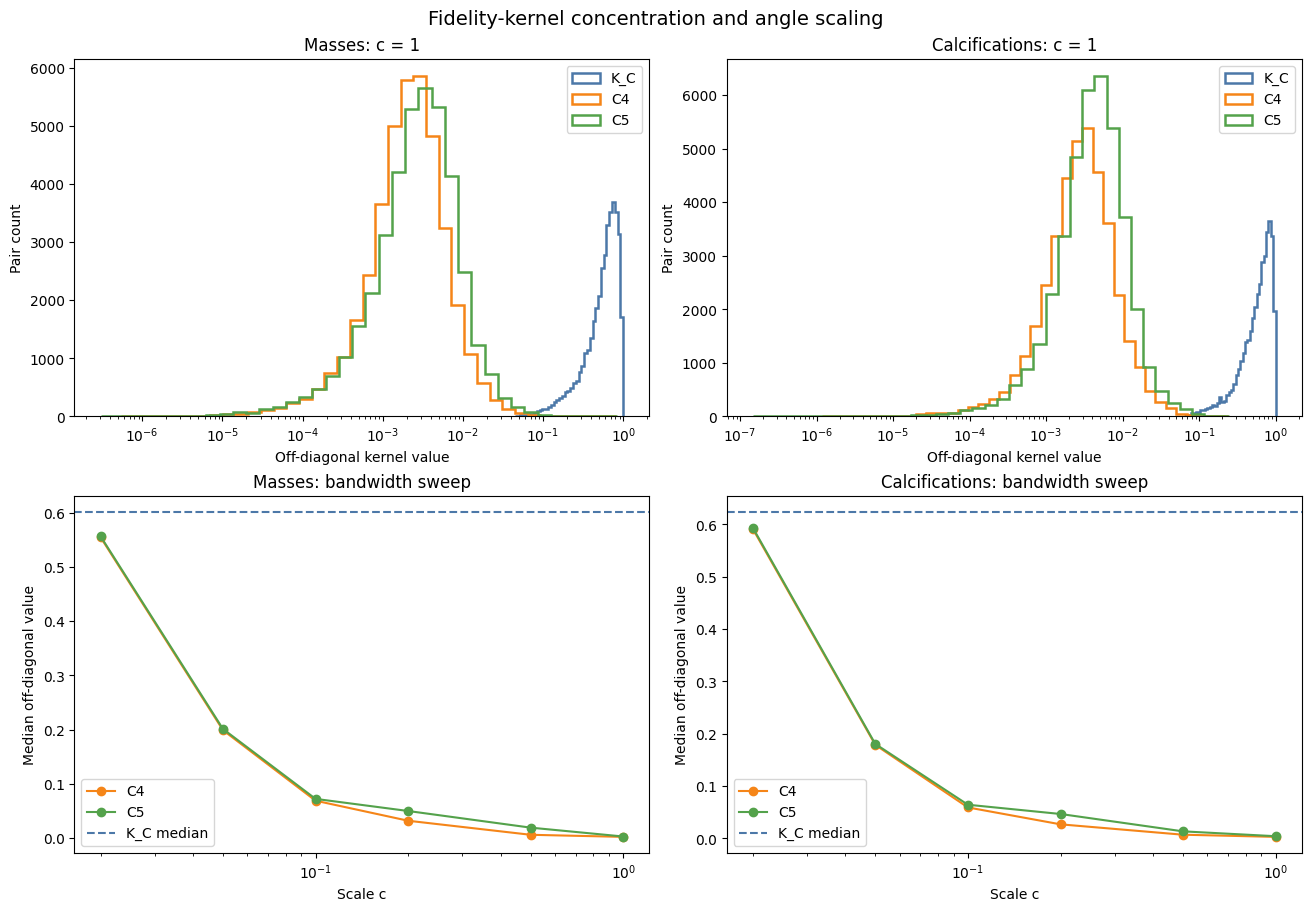

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
colors = {'K_C': '#4C78A8', 'C4': '#F58518', 'C5': '#54A24B'}
titles = {'mass': 'Masses', 'calcification': 'Calcifications'}
for col, finding in enumerate(FINDINGS):
    ax = axes[0, col]
    for label, key in [('K_C', 'K_C'), ('C4', 'K_Q_C4'), ('C5', 'K_Q_C5')]:
        vals = off_diagonal(kernels[finding][key])
        vals = vals[vals > 0]
        ax.hist(vals, bins=np.logspace(np.log10(vals.min()), np.log10(vals.max()), 40), histtype='step', linewidth=1.8, label=label, color=colors[label])
    ax.set_xscale('log'); ax.set_title(f'{titles[finding]}: c = 1'); ax.set_xlabel('Off-diagonal kernel value'); ax.set_ylabel('Pair count'); ax.legend()
    ax = axes[1, col]
    for label in ['C4', 'C5']:
        part = concentration[(concentration.finding_type == finding) & (concentration.kernel == label)].sort_values('c')
        ax.plot(part.c, part.median_off_diagonal, marker='o', label=label, color=colors[label])
    classical_median = concentration[(concentration.finding_type == finding) & (concentration.kernel == 'K_C')].median_off_diagonal.iloc[0]
    ax.axhline(classical_median, color=colors['K_C'], linestyle='--', label='K_C median')
    ax.set_xscale('log'); ax.set_title(f'{titles[finding]}: bandwidth sweep'); ax.set_xlabel('Scale c'); ax.set_ylabel('Median off-diagonal value'); ax.legend()
fig.suptitle('Fidelity-kernel concentration and angle scaling', fontsize=14)
fig.savefig(FIG_DIR / 'M5_kernel_concentration.png', dpi=180, bbox_inches='tight')
plt.show()

#### **5° Exactness and implementation checks**

**a.** Compare statevector and circuit-level fidelity calculations

The checks confirm symmetry, unit diagonal, range, and positive semidefiniteness. Five deterministic off-diagonal pairs per quantum kernel are independently reconstructed from `Statevector`; a 10-by-10 block also compares `FidelityQuantumKernel` with its default constructor against the statevector implementation. The latter timing represents an exact circuit-level simulation, not hardware sampling.

In [7]:
verification_rows = []
rng = np.random.default_rng(SEED)
for finding in FINDINGS:
    for key, K in kernels[finding].items():
        if not key.startswith('K_'):
            continue
        eigmin = np.linalg.eigvalsh(K).min()
        metrics = {'symmetry_max_abs': np.max(np.abs(K - K.T)), 'diagonal_max_abs_error': np.max(np.abs(np.diag(K) - 1.0)), 'min_entry': K.min(), 'max_entry': K.max(), 'min_eigenvalue': eigmin}
        passed = metrics['symmetry_max_abs'] <= 1e-12 and metrics['diagonal_max_abs_error'] <= 1e-12 and metrics['min_entry'] >= -1e-12 and metrics['max_entry'] <= 1 + 1e-12 and eigmin >= -1e-10
        verification_rows.append({'finding_type': finding, 'check': f'matrix_{key}', 'max_abs_difference': max(metrics['symmetry_max_abs'], metrics['diagonal_max_abs_error'], max(0., -metrics['min_entry']), max(0., metrics['max_entry'] - 1), max(0., -eigmin)), 'threshold': 1e-10, 'passed': passed, **metrics})
    X = Xs[finding]
    for name, fmap in feature_maps.items():
        K = kernels[finding][f'K_Q_{name}']
        pairs = []
        while len(pairs) < 5:
            i, j = rng.choice(len(X), size=2, replace=False)
            if i != j: pairs.append((int(i), int(j)))
        errors = []
        for i, j in pairs:
            si = Statevector(fmap.assign_parameters(dict(zip(fmap.parameters, X[i]))))
            sj = Statevector(fmap.assign_parameters(dict(zip(fmap.parameters, X[j]))))
            errors.append(abs(K[i, j] - abs(np.vdot(si.data, sj.data)) ** 2))
        verification_rows.append({'finding_type': finding, 'check': f'independent_statevector_{name}', 'max_abs_difference': max(errors), 'threshold': 1e-12, 'passed': max(errors) <= 1e-12})
        t0 = time.perf_counter()
        quantum_block = FidelityQuantumKernel(feature_map=fmap).evaluate(X[:10])
        elapsed = time.perf_counter() - t0
        statevector_block = FidelityStatevectorKernel(feature_map=fmap).evaluate(X[:10])
        diff = np.max(np.abs(quantum_block - statevector_block))
        timing_rows.append({'finding_type': finding, 'kernel': f'FidelityQuantumKernel_{name}', 'shape': '10x10', 'seconds': elapsed})
        verification_rows.append({'finding_type': finding, 'check': f'quantum_vs_statevector_10x10_{name}', 'max_abs_difference': diff, 'threshold': 1e-10, 'passed': diff <= 1e-10})
verifications = pd.DataFrame(verification_rows)
verifications.to_csv(RESULTS_DIR / '5b_verificaciones.csv', index=False)
times = pd.DataFrame(timing_rows)
times.to_csv(RESULTS_DIR / '5b_tiempos.csv', index=False)
print(f'All checks passed: {verifications.passed.all()}')
display(verifications[['finding_type', 'check', 'max_abs_difference', 'threshold', 'passed']])
display(times)

All checks passed: True


,finding_type,check,max_abs_difference,threshold,passed
0,mass,matrix_K_C,8.881784e-16,1.000000e-10,True
1,mass,matrix_K_Q_C4,0.000000e+00,1.000000e-10,True
2,mass,matrix_K_Q_C4_c1.0,0.000000e+00,1.000000e-10,True
3,mass,matrix_K_Q_C4_c0.5,0.000000e+00,1.000000e-10,True
4,mass,matrix_K_Q_C4_c0.2,0.000000e+00,1.000000e-10,True
5,mass,matrix_K_Q_C4_c0.1,0.000000e+00,1.000000e-10,True
6,mass,matrix_K_Q_C4_c0.05,0.000000e+00,1.000000e-10,True
7,mass,matrix_K_Q_C4_c0.02,0.000000e+00,1.000000e-10,True
8,mass,matrix_K_Q_C5,0.000000e+00,1.000000e-10,True
9,mass,matrix_K_Q_C5_c1.0,0.000000e+00,1.000000e-10,True


,finding_type,kernel,shape,seconds
0,mass,FidelityStatevectorKernel_C4,200x200,1.546126
1,mass,FidelityStatevectorKernel_C5,200x200,1.626301
2,calcification,FidelityStatevectorKernel_C4,200x200,1.598536
3,calcification,FidelityStatevectorKernel_C5,200x200,1.708982
4,mass,FidelityQuantumKernel_C4,10x10,5.011156
5,mass,FidelityQuantumKernel_C5,10x10,3.319933
6,calcification,FidelityQuantumKernel_C4,10x10,5.016644
7,calcification,FidelityQuantumKernel_C5,10x10,3.363680


#### **6° Why the kernel concentrates**

**a.** Phase accumulation in the ZZ feature map

For each pair of features, `zz_feature_map` applies the $Z_iZ_j$ phase $2(\pi-x_i)(\pi-x_j)$. With complete entanglement at 12 qubits there are 66 pairs, and every qubit participates in 11 of them. Therefore the phase changes with $x_i$ at a rate of $2$ from its single-qubit term plus $\sum_{j\ne i}2(\pi-x_j)$ from its pair terms; the following calculation measures that second contribution on the 200 selected lesions.

After angle scaling $x\mapsto c x$, a pair phase becomes $2\pi^2-2\pi c(x_i+x_j)+2c^2x_ix_j$. The constant term is input-independent and cancels from the fidelity. The linear term remains a data-dependent $Z_iZ_j$ phase, but it encodes only the sums $x_i+x_j$; the product $x_ix_j$, which is the feature interaction, is order $c^2$ and vanishes more rapidly as $c$ decreases. This is the mechanism examined below for H-031 and the sensitivity analysis retained by D-029.

In [8]:
def no_product(x):
    return x[0] if len(x) == 1 else np.pi**2 - np.pi * (x[0] + x[1])

no_product_map = zz_feature_map(12, reps=1, data_map_func=no_product)
mechanism_rows, phase_rows = [], []
for finding in FINDINGS:
    X = Xs[finding]
    pair_rate = 2.0 * (np.sum(np.pi - X, axis=1, keepdims=True) - (np.pi - X))
    phase_rows.append({'finding_type': finding, 'median_pair_rate': np.median(pair_rate), 'min_pair_rate': pair_rate.min(), 'max_pair_rate': pair_rate.max(), 'median_ratio_to_single_qubit_rate': np.median(pair_rate) / 2.0})
    for c in [1.0, 0.2, 0.05, 0.02]:
        complete = FidelityStatevectorKernel(feature_map=feature_maps['C4']).evaluate(c * X)
        without_product = FidelityStatevectorKernel(feature_map=no_product_map).evaluate(c * X)
        complete_values = off_diagonal(complete)
        no_product_values = off_diagonal(without_product)
        mechanism_rows.append({'finding_type': finding, 'c': c, 'complete_median': np.median(complete_values), 'no_product_median': np.median(no_product_values), 'mean_absolute_difference': np.mean(np.abs(complete_values - no_product_values)), 'pearson_correlation': np.corrcoef(complete_values, no_product_values)[0, 1]})
phase_diagnostics = pd.DataFrame(phase_rows)
mechanism_diagnostics = pd.DataFrame(mechanism_rows)
display(phase_diagnostics)
display(mechanism_diagnostics)

,finding_type,median_pair_rate,min_pair_rate,max_pair_rate,median_ratio_to_single_qubit_rate
0,mass,36.345107,2.760066,64.637266,18.172553
1,calcification,35.264922,17.278868,49.176096,17.632461


,finding_type,c,complete_median,no_product_median,mean_absolute_difference,pearson_correlation
0,mass,1.00,0.002157,0.000198,0.002963,0.700210
1,mass,0.20,0.031915,0.032410,0.004460,0.982577
2,mass,0.05,0.198971,0.192778,0.007472,0.999630
3,mass,0.02,0.554926,0.550449,0.003807,0.999970
4,calcification,1.00,0.002861,0.000228,0.003624,0.690839
5,calcification,0.20,0.026827,0.027989,0.004687,0.988260
6,calcification,0.05,0.178676,0.171298,0.007582,0.999800
7,calcification,0.02,0.591271,0.586371,0.004221,0.999988


**b.** Numerical conclusion

For masses, the median pair contribution is 36.35, with a range from 2.76 to 64.64; this is 18.17 times the single-qubit rate of 2. For calcifications it is 35.26 (17.28--49.18), or 17.63 times that rate.

The complete/no-product off-diagonal medians, mean absolute differences, and Pearson correlations are respectively: for masses at $c=(1,0.2,0.05,0.02)$, $(0.002157/0.000198, 0.002963, 0.700210)$, $(0.031915/0.032410, 0.004460, 0.982577)$, $(0.198971/0.192778, 0.007472, 0.999630)$, and $(0.554926/0.550449, 0.003807, 0.999970)$; for calcifications they are $(0.002861/0.000228, 0.003624, 0.690839)$, $(0.026827/0.027989, 0.004687, 0.988260)$, $(0.178676/0.171298, 0.007582, 0.999800)$, and $(0.591271/0.586371, 0.004221, 0.999988)$. Thus the kernel becomes non-concentrated only at scales where the product contribution no longer materially changes it, as the near-one correlations at $c=0.02$ show.

#### **7° Consequence**

**a.** Concentration at the preregistered scale

At $c=1$, the mass RBF median is 0.601604, compared with 0.002157 for C4 and 0.002842 for C5. The fractions below $10^{-3}$ are 0.233116 (C4) and 0.196332 (C5), and the minimum eigenvalues are 0.174442 and 0.160008.

For calcifications, the RBF median is 0.623886, while C4 and C5 are 0.002861 and 0.004137. Their fractions below $10^{-3}$ are 0.159648 and 0.099146, and their minimum eigenvalues are 0.756438 and 0.749977.

**b.** Bandwidth sweep

For masses, the C4 medians at $c=(1,0.5,0.2,0.1,0.05,0.02)$ are (0.002157, 0.006012, 0.031915, 0.068891, 0.198971, 0.554926); C5 gives (0.002842, 0.019196, 0.049875, 0.072239, 0.201263, 0.556802). For calcifications, C4 gives (0.002861, 0.006999, 0.026827, 0.059133, 0.178676, 0.591271) and C5 gives (0.004137, 0.013425, 0.046600, 0.064291, 0.180455, 0.593546).

**c.** Exact simulation time and the OE-6 limitation

`FidelityStatevectorKernel` evaluated the 200-by-200 matrices in 1.546 s (mass C4), 1.626 s (mass C5), 1.599 s (calcification C4), and 1.709 s (calcification C5). In contrast, `FidelityQuantumKernel` took 5.011 s, 3.320 s, 5.017 s, and 3.364 s respectively for the 10-by-10 blocks (45 distinct pairs): 0.111359, 0.073776, 0.111481, and 0.074748 s per pair, which project to 36.93, 24.47, 36.97, and 24.79 min for 19,900 pairs in a 200-by-200 matrix.

`FidelityStatevectorKernel` obtains this simulation speed by accessing a statevector, which is not available on real hardware. There, every kernel entry requires circuit executions and probability estimation from shots; resolving values near 0.002 would require many shots.

In [9]:
summary = concentration.query("kernel in ['C4', 'C5'] and c in [1.0, 0.02]")[['finding_type', 'kernel', 'c', 'median_off_diagonal', 'fraction_lt_1e-3']].sort_values(['finding_type', 'kernel', 'c'], ascending=[True, True, False])
display(summary)
display(pd.DataFrame({'finding_type': list(gammas), 'gamma': list(gammas.values())}))
print(f'Matrix/check rows passed: {int(verifications.passed.sum())}/{len(verifications)}')

,finding_type,kernel,c,median_off_diagonal,fraction_lt_1e-3
14,calcification,C4,1.00,0.002861,0.159648
19,calcification,C4,0.02,0.591271,0.000000
20,calcification,C5,1.00,0.004137,0.099146
25,calcification,C5,0.02,0.593546,0.000000
1,mass,C4,1.00,0.002157,0.233116
6,mass,C4,0.02,0.554926,0.000000
7,mass,C5,1.00,0.002842,0.196332
12,mass,C5,0.02,0.556802,0.000000


,finding_type,gamma
0,mass,0.032220
1,calcification,0.032089


Matrix/check rows passed: 38/38
